<h1 align = "center"> Machine Learning Fundamentals </h1>

## Data loading and exploration

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Q1: Load the Iris dataset using sklearn.datasets.load_iris() and print feature_names, target_names, and the shape of data.

In [26]:
from sklearn.datasets import load_iris
iris = load_iris()

print("Feature_names: ", iris['feature_names'])
print("Target_names: ", iris['target_names'])
print("Shape: ", iris['data'].shape)

Feature_names:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target_names:  ['setosa' 'versicolor' 'virginica']
Shape:  (150, 4)


### Q2: Provide a short written answer: What type of problem is this (classification/regression)? Why? Write your answer in a Markdown cell below.

The type of this problem is classification. Because our target is to define the class / type of iris in which flower belongs to. 

### Q3: Show the first five rows of the data as a pandas DataFrame with column names from feature_names.

In [38]:
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Q4: Report class distribution (counts for each species)

In [39]:
df['species'] = iris.target
df['species'].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

## Visualisation

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'], random_state=0, stratify = iris['target'])

### Q5: Create a pair plot (scatter plot matrix) for the four features using matplotlib. Color points by species.

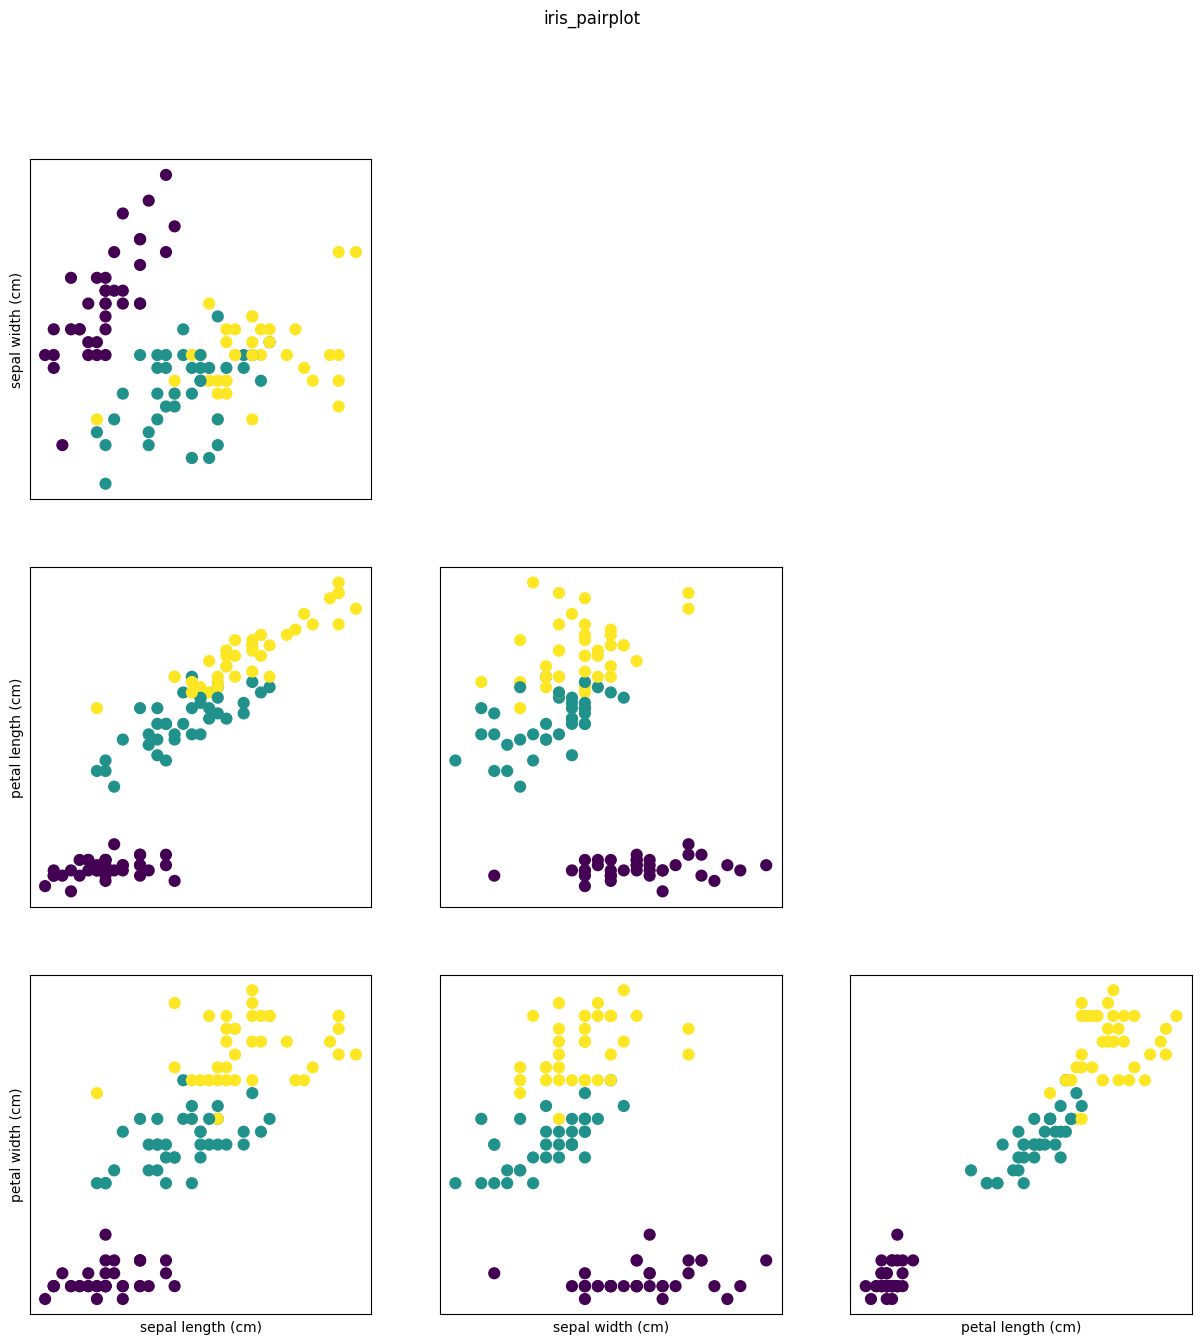

In [56]:
fig, ax = plt.subplots(3, 3, figsize=(15, 15))
plt.suptitle("iris_pairplot")
for i in range(3):
     for j in range(3):
         ax[i, j].scatter(X_train[:, j], X_train[:, i + 1], c=y_train, s=60)
         ax[i, j].set_xticks(())
         ax[i, j].set_yticks(())
         if i == 2:
             ax[i, j].set_xlabel(iris['feature_names'][j])
         if j == 0:
             ax[i, j].set_ylabel(iris['feature_names'][i + 1])
         if j > i:
             ax[i, j].set_visible(False)

### Q6: Based on your plot, which two features appear most useful to separate the classes? Explain in one short sentence.

petal.width + petal length

## Train - Test - split and KNN modeling

### Q7: Split the data into train/test sets (75% train, 25% test). Use stratify=target and random_state=42. Print shapes.

In [59]:
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'], test_size = 0.25, random_state=42, stratify = iris['target'])
print(X_train.shape)
print(X_test.shape)

(112, 4)
(38, 4)


### Q8: Train a KNeighborsClassifier with n_neighbors=3. Fit on training data and report test accuracy.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors = 3)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

knn_model.score(X_test, y_test)

0.9421613394216134

### 9: Compare accuracy for n_neighbors = 1, 3, 5. Report which k gives best accuracy and why (short sentence).

In [ ]:
neighbors_list = [1, 3, 5]
for i in neighbors_list:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print(knn.score(X_test, y_test))

0.9199157007376185
0.9421613394216134
0.9519494204425711
